Max Depth: 3
  Training Accuracy: 83.43 %
  Test Accuracy: 81.01 %

Max Depth: 5
  Training Accuracy: 85.39 %
  Test Accuracy: 82.68 %

Max Depth: 7
  Training Accuracy: 89.47 %
  Test Accuracy: 80.45 %

Max Depth: 9
  Training Accuracy: 93.12 %
  Test Accuracy: 82.68 %

Max Depth: 11
  Training Accuracy: 95.79 %
  Test Accuracy: 82.12 %

Max Depth: None
  Training Accuracy: 98.03 %
  Test Accuracy: 81.01 %



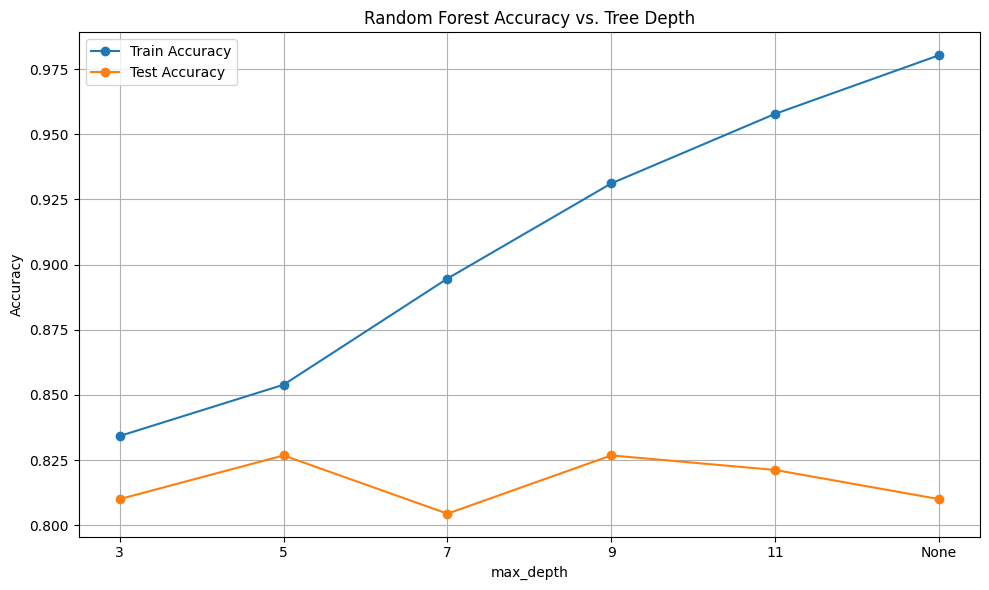

In [8]:
# Day 20: Random Forest Depth Tuning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("../day02-python-problems/cleaned_titanic.csv")

# Define features and target
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone"]
X = df[features]
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try multiple max_depth values
depth_values = [3, 5, 7, 9, 11, None]
train_accuracies = []
test_accuracies = []

for depth in depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Max Depth: {depth}")
    print(f"  Training Accuracy: {round(train_acc * 100, 2)} %")
    print(f"  Test Accuracy: {round(test_acc * 100, 2)} %\n")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in depth_values], train_accuracies, marker='o', label="Train Accuracy")
plt.plot([str(d) for d in depth_values], test_accuracies, marker='o', label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs. Tree Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
